<style>
    body {
        font-family: 'Arial', sans-serif;
        background-color: #f4f4f4;
        color: #333;
        line-height: 1.6;
    }

    .main-container {
        max-width: 940px;
        margin: 20px auto;
        background-color: #ffffff;
        border-radius: 8px;
        box-shadow: 0 2px 10px rgba(0, 0, 0, 0.1);
        padding: 20px;
    }

    h1.title {
        font-size: 3em;
        color: #0056b3; /* Darker blue for a more professional look */
        margin-bottom: 20px;
        font-weight: bold; /* Bold for emphasis */
        text-align: center; /* Center the title */
    }

    h2 {
        font-size: 2em;
        color: #007bff; /* Lighter blue for subheadings */
        margin-top: 40px;
        margin-bottom: 10px;
        font-weight: 600; /* Semi-bold for better visibility */
        border-bottom: 2px solid #e9ecef; /* Underline for emphasis */
        padding-bottom: 5px; /* Space below the heading */
    }

    h3 {
        font-size: 1.75em;
        color: #0056b3;
        margin-top: 20px;
        margin-bottom: 10px;
        font-weight: 500; /* Medium weight for sub-subheadings */
    }

    p {
        font-size: 1.2em;
        margin-bottom: 10px;
        line-height: 1.5; /* Increased line height for better readability */
    }

    pre {
        background-color: #f8f9fa;
        padding: 15px;
        border-radius: 5px;
        overflow-x: auto;
        border: 1px solid #ddd;
    }

    code {
        background-color: #e9ecef;
        padding: 2px 4px;
        border-radius: 4px;
    }

    .dataframe-container {
        overflow-x: auto; /* Enable horizontal scrolling */
        margin-bottom: 20px; /* Space below the DataFrame */
        border: 1px solid #ddd; /* Optional border for better visibility */
        border-radius: 5px; /* Rounded corners */
    }

    table {
        width: 100%; /* Ensure the table takes full width */
        border-collapse: collapse; /* Remove space between cells */
    }

    th, td {
        padding: 10px; /* Padding for table cells */
        text-align: left; /* Align text to the left */
        border-bottom: 1px solid #ddd; /* Light border for separation */
    }

    th {
        background-color: #ffffff; /* Change header background color to white */
        color: #333; /* Header text color */
        font-weight: bold; /* Bold header text */
    }

    tr:hover {
        background-color: #f1f1f1; /* Highlight row on hover */
    }

    .footer {
        text-align: center;
        margin-top: 20px;
        font-size: 0.9em;
        color: #6c757d;
    }

    /* Responsive adjustments */
    @media (max-width: 768px) {
        .main-container {
            padding: 15px;
        }

        h1.title {
            font-size: 2em;
        }

        h2, h3 {
            font-size: 1.5em;
        }
    }
</style>

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display the DataFrame in a scrollable container
from IPython.core.display import display, HTML

C:\Users\Ondřej Černý\AppData\Local\Temp\ipykernel_9352\1687919583.py:7: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [70]:
misconception_mapping = pd.read_csv('./data/misconception_mapping.csv')
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')
sample_submission = pd.read_csv('./data/sample_submission.csv')

# Report Overview
This is a report of my semestral work for a subject called NI-MLP at the FIT CTU.

The result of this work is used as a submission at a Kaggle competition called: Eedi - Mining Misconceptions in Mathematics (link [here](vhttps://www.kaggle.com/competitions/eedi-mining-misconceptions-in-mathematics/overview)). The goal of this competition and therefore, also of this work is to develop an NLP model to predict the affinity between misconceptions and incorrect answers (distractors) in multiple-choice questions. This solution will suggest candidate misconceptions for distractors. 

In this report I will describe the task at hand, describe the data given, preprocess the data, train appropriate NLP model and summarize the resulting work.

However, this notebook covers only the task and data description and data preprocessing. The model creation, its training and can be found in files called `similarity_seach.html`, `fine_tuning_bge_large.html` and `zero_shot.html` (this file also contains work summary at the end). 

Its recommended to read this notebook first, then `similarity_seach.html` followed by `fine_tuning_bge_large.html` and `zero_shot.html` as last.

# Task Description

The goal of this competition is to predict possible misconceptions given a incorrect answer to a mathematical question.

Each question is a multiple-choice with four options: one correct answer and tree distractors  (incorrect answers). If a student pics a distractor as his answer our goal is to then label his choice with a specific misconception. For example:

![Example Question](example_description.png)

In this question the correct answer is A(23), but if student selects as his answer B(13) our task is to label this incorrect choice of answer with a misconception such as, "Carries out operations from left to right regardless of priority order."

# Data Description
I am provided with 4 datasets which are `train.csv`, `test.csv`, `misconception_mapping.csv` and `sample_submission.csv`.

## Train and Test Datasets
Train and test datasets contain the following attributes:

- `QuestionId` - Unique question identifier (int).
- `ConstructId` - Unique construct identifier (int) .
- `ConstructName` - Most granular level of knowledge related to question (str).
- `CorrectAnswer` - A, B, C or D (char).
- `SubjectId` - Unique subject identifier (int).
- `SubjectName` - More general context than the construct (str).
- `QuestionText` - Question text extracted from the question image using human-in-the-loop OCR (str) .
- `Answer[A/B/C/D]Text` - Answer text for a given option (str).
- `Misconception[A/B/C/D]Id` - Unique misconception identifier (int). Ground truth labels in `train.csv`; our task is to predict these labels for `test.csv`.

Therefore a single row in `train.csv` looks the following:

In [71]:
# Print attribute names and their values of a single row
for attribute, value in train_df.iloc[0].items():
    print(f"{attribute}: {value}")

QuestionId: 0
ConstructId: 856
ConstructName: Use the order of operations to carry out calculations involving powers
SubjectId: 33
SubjectName: BIDMAS
CorrectAnswer: A
QuestionText: \[
3 \times 2+4-5
\]
Where do the brackets need to go to make the answer equal \( 13 \) ?
AnswerAText: \( 3 \times(2+4)-5 \)
AnswerBText: \( 3 \times 2+(4-5) \)
AnswerCText: \( 3 \times(2+4-5) \)
AnswerDText: Does not need brackets
MisconceptionAId: nan
MisconceptionBId: nan
MisconceptionCId: nan
MisconceptionDId: 1672.0


## Misconception Mapping Dataset
Contains only two attributes of `MisconceptionId` (int) and `MisconceptionName` (str). Its purpose is it map `MisconceptionId` to its `MisconceptionName`.

A single row in `misconception_mapping.csv` can look the following:

In [72]:
# Print attribute names and their values of a single row
for attribute, value in misconception_mapping.iloc[0].items():
    print(f"{attribute}: {value}")

MisconceptionId: 0
MisconceptionName: Does not know that angles in a triangle sum to 180 degrees


## Sample Submission Dataset
Example file of a correct submission format. It will contain two attributes:
- `QuestionId_Answer` - Each question has three incorrect answers for which need you predict the MisconceptionId.
- `MisconceptionId` - Predicted 25 most likely `MisconceptionId` values, space delimited.

The first 3 rows of this dataset look the following:

In [73]:
sample_submission.head(3)

,QuestionId_Answer,MisconceptionId
0,1869_B,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...
1,1869_C,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...
2,1869_D,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...


### Evaluation
Submissions are evaluated according to the Mean Average Precision @ 25 (MAP@25):
$$
MAP@25=\frac{1}{U}\sum_{u=1}^{U}\sum_{k=1}^{min(n,25)}{P(k)} \times {rel(k)}
$$
where $U$ is the number of observations, $P(k)$ is the precision at cutoff $k$, $n$ is the number predictions submitted per observation, and $rel(k)$ is an indicator function equaling $1$ if the item at rank $k$ is a relevant (correct) label, zero otherwise.

Once a correct label has been scored for an observation, that label is no longer considered relevant for that observation, and additional predictions of that label are skipped in the calculation. For example, if the correct label is A for an observation, the following predictions all score an average precision of 1.0.

[A, B, C, D, E]<br>
[A, A, A, A, A]<br>
[A, B, A, C, A]

There is only one correct label per observation (hence no divisor term in front of the inner summation).

# Data Preprocessing

In this section I examine the data provided and check for possible data imbalances, data integrity and preprocess the data.

## Examine Misconception Mapping Dataset


First 5 rows of the Misconception Mapping dataset look the following:

In [74]:
misconception_mapping.head()

,MisconceptionId,MisconceptionName
0,0,Does not know that angles in a triangle sum to...
1,1,Uses dividing fractions method for multiplying...
2,2,Believes there are 100 degrees in a full turn
3,3,Thinks a quadratic without a non variable term...
4,4,Believes addition of terms and powers of terms...


### Check for Duplicates
Counting the occurrences of each unique value in the `MisconceptionName` column. If all occurrences equal 1 then there are no duplicate values.<br>
Do also the same for `MisconceptionId`.

In [75]:
if max(misconception_mapping['MisconceptionName'].value_counts()) == 1:
    print("There are duplicate values in the 'MisconceptionName' column.")
if max(misconception_mapping['MisconceptionId'].value_counts()) == 1:
    print("There are duplicate values in the 'MisconceptionId' column.")

There are duplicate values in the 'MisconceptionName' column.
There are duplicate values in the 'MisconceptionId' column.


### Datasets Shape

In [76]:
print(f"Misconceptions Mapping Dataset shape is: {misconception_mapping.shape}")

Misconceptions Mapping Dataset shape is: (2587, 2)


This means that there are 2587 unique misconceptions to choose from when I will labelling the incorrect answers. 

### `MisconceptionName` values lengths
Since `MisconceptionName` values are strings, lets analyze lengths (in tokens) of these strings and plot histogram of them.

Median Length: 66.0
Mean Length: 70.42133745651334
Standard Deviation: 29.38876377566029
Min Length: 14
Max Length: 209


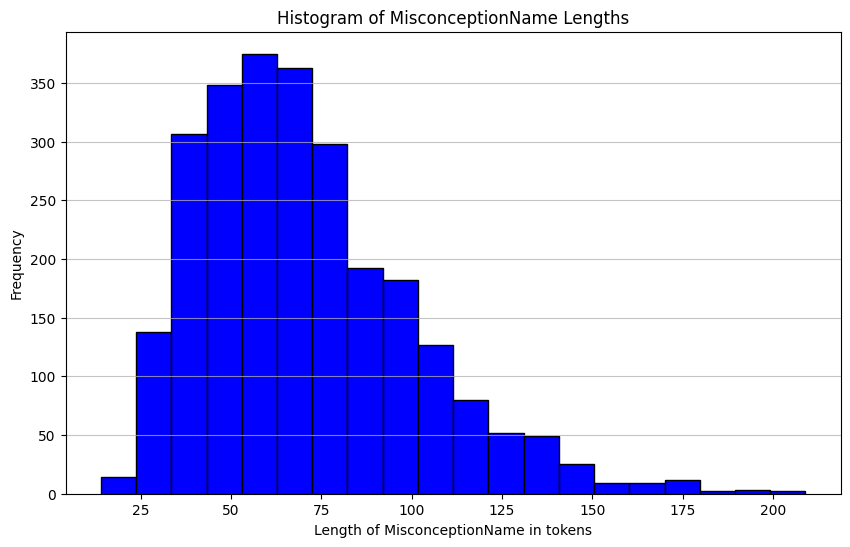

In [77]:
# Calculate lengths of MisconceptionName values
lengths = misconception_mapping['MisconceptionName'].str.len()

mean_length = lengths.mean()
min_length = lengths.min()
max_length = lengths.max()
median_length = lengths.median()
std_dev_length = lengths.std()
print(f'Median Length: {median_length}')
print(f'Mean Length: {mean_length}')
print(f'Standard Deviation: {std_dev_length}')
print(f'Min Length: {min_length}')
print(f'Max Length: {max_length}')

# Create a histogram of the lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=20, color='blue', edgecolor='black')
plt.title('Histogram of MisconceptionName Lengths')
plt.xlabel('Length of MisconceptionName in tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

As seen in the graph above, all values are shorter then 209 tokens and most of them are 40 to 100 tokens long.

## Examine Test Dataset


### Shape of Test Dataset

In [78]:
display(test_df.shape)

(3, 11)

The test dataset provided has only 3 rows, its only purpose is to show how the evaluation dataset (which is hidden from us) is gonna look. But since it has only 3 rows I will be actually using a part of training dataset as the test dataset for my models (more about this in Model Selection and Train-Test Split chapter later).

### Display the Dataset

In [79]:
display(HTML(f'<div class="dataframe-container">{test_df.head().to_html(index=False)}</div>'))

QuestionId,ConstructId,ConstructName,SubjectId,SubjectName,CorrectAnswer,QuestionText,AnswerAText,AnswerBText,AnswerCText,AnswerDText
1869,856,Use the order of operations to carry out calculations involving powers,33,BIDMAS,A,\[\n3 \times 2+4-5\n\]\nWhere do the brackets need to go to make the answer equal \( 13 \) ?,\( 3 \times(2+4)-5 \),\( 3 \times 2+(4-5) \),\( 3 \times(2+4-5) \),Does not need brackets
1870,1612,Simplify an algebraic fraction by factorising the numerator,1077,Simplifying Algebraic Fractions,D,"Simplify the following, if possible: \( \frac{m^{2}+2 m-3}{m-3} \)",\( m+1 \),\( m+2 \),\( m-1 \),Does not simplify
1871,2774,Calculate the range from a list of data,339,Range and Interquartile Range from a List of Data,B,"Tom and Katie are discussing the \( 5 \) plants with these heights:\n\( 24 \mathrm{~cm}, 17 \mathrm{~cm}, 42 \mathrm{~cm}, 26 \mathrm{~cm}, 13 \mathrm{~cm} \)\nTom says if all the plants were cut in half, the range wouldn't change.\nKatie says if all the plants grew by \( 3 \mathrm{~cm} \) each, the range wouldn't change.\nWho do you agree with?",Only\nTom,Only\nKatie,Both Tom and Katie,Neither is correct


As seen and also said before, the test dataset (`test.csv`) is the same as the train dataset (`train.csv`) apart from the fact that it misses 4 columns called `MisconceptionAId`, `MisconceptionBId`, `MisconceptionCId` and `MisconceptionDId`. These are the columns whose values I am supposed to predict.

## Examine Train Dataset


### Shape of Train Dataset

In [80]:
display(train_df.shape)

(1869, 15)

Train dataset has 1869 rows and 15 columns.

### Display the first few rows

In [81]:
display(HTML(f'<div class="dataframe-container">{train_df.head().to_html(index=False)}</div>'))

QuestionId,ConstructId,ConstructName,SubjectId,SubjectName,CorrectAnswer,QuestionText,AnswerAText,AnswerBText,AnswerCText,AnswerDText,MisconceptionAId,MisconceptionBId,MisconceptionCId,MisconceptionDId
0,856,Use the order of operations to carry out calculations involving powers,33,BIDMAS,A,\[\n3 \times 2+4-5\n\]\nWhere do the brackets need to go to make the answer equal \( 13 \) ?,\( 3 \times(2+4)-5 \),\( 3 \times 2+(4-5) \),\( 3 \times(2+4-5) \),Does not need brackets,NaN,NaN,NaN,1672.0
1,1612,Simplify an algebraic fraction by factorising the numerator,1077,Simplifying Algebraic Fractions,D,"Simplify the following, if possible: \( \frac{m^{2}+2 m-3}{m-3} \)",\( m+1 \),\( m+2 \),\( m-1 \),Does not simplify,2142.0,143.0,2142.0,NaN
2,2774,Calculate the range from a list of data,339,Range and Interquartile Range from a List of Data,B,"Tom and Katie are discussing the \( 5 \) plants with these heights:\n\( 24 \mathrm{~cm}, 17 \mathrm{~cm}, 42 \mathrm{~cm}, 26 \mathrm{~cm}, 13 \mathrm{~cm} \)\nTom says if all the plants were cut in half, the range wouldn't change.\nKatie says if all the plants grew by \( 3 \mathrm{~cm} \) each, the range wouldn't change.\nWho do you agree with?",Only\nTom,Only\nKatie,Both Tom and Katie,Neither is correct,1287.0,NaN,1287.0,1073.0
3,2377,Recall and use the intersecting diagonals properties of a rectangle,88,Properties of Quadrilaterals,C,The angles highlighted on this rectangle with different length sides can never be... ![A rectangle with the diagonals drawn in. The angle on the right hand side at the centre is highlighted in red and the angle at the bottom at the centre is highlighted in yellow.](),acute,obtuse,\( 90^{\circ} \),Not enough information,1180.0,1180.0,NaN,1180.0
4,3387,Substitute positive integer values into formulae involving powers or roots,67,Substitution into Formula,A,The equation \( f=3 r^{2}+3 \) is used to find values in the table below. What is the value covered by the star? \begin{tabular}{|c|c|c|c|c|}\n\hline\( r \) & \( 1 \) & \( 2 \) & \( 3 \) & \( 4 \) \\\n\hline\( f \) & \( 6 \) & \( 15 \) & \( \color{gold}\bigstar \) & \\\n\hline\n\end{tabular},\( 30 \),\( 27 \),\( 51 \),\( 24 \),NaN,NaN,NaN,1818.0


### Print number of NaN values

In [82]:
train_df.isna().sum()

QuestionId            0
ConstructId           0
ConstructName         0
SubjectId             0
SubjectName           0
CorrectAnswer         0
QuestionText          0
AnswerAText           0
AnswerBText           0
AnswerCText           0
AnswerDText           0
MisconceptionAId    734
MisconceptionBId    751
MisconceptionCId    789
MisconceptionDId    832
dtype: int64

As seen above, the dataset doesn't contain any NaN values, apart from the `MisconceptionId` columns (which is the one whose value I am going to predict). This mean there is no need to impute any missing values.

### Check if all `QuestionIds` are unique
Check if there are no duplicate `QuestionIds`

In [83]:
if (train_df['QuestionId'].nunique() == train_df.shape[0]):
    print('There is no duplicate QuestionId')
else:
    print('There are duplicate QuestionId')

There is no duplicate QuestionId


### Check data integrity
Check data integrity between `ConstructId` and `ConstructName` columns and also between `SubjectId` and `SubjectName` columns.<br>
I.E.: Check whether for a single `Id` value there is only one `Name` value and vice versa.

In [84]:
def check_integrity(column_id: str, column_name: str) -> None:
    """
    Check data integrity between column Name values and ID values.
    Checks if there are multiple Name values for a single ID value or vice versa.

    Args:
        column_id (str): The column name with id values.
        column_name (str): The column name with string/name values.
    """
    # Group by id values and count unique name values
    integrity_issues_id = train_df.groupby(column_id)[column_name].nunique()

    # Filter for id values with more than one unique name value
    integrity_issues_id = integrity_issues_id[integrity_issues_id > 1]

    if not integrity_issues_id.empty:
        print(f"DF has multiple {column_name} values for a single {column_id} value.")
        print(f"{integrity_issues_id}\n")
        
    integrity_issues_name = train_df.groupby(column_name)[column_id].nunique()
    integrity_issues_name = integrity_issues_name[integrity_issues_name > 1]
    
    if not integrity_issues_name.empty:
        print(f"DF has multiple {column_id} values for a single {column_name} value.")
        print(f"{integrity_issues_name}\n")
        
    if integrity_issues_id.empty and integrity_issues_name.empty:
        print(f"No integrity issues found between {column_id} and {column_name}.")
        
check_integrity(column_id='ConstructId', column_name='ConstructName')
check_integrity(column_id='SubjectId', column_name='SubjectName')

No integrity issues found between ConstructId and ConstructName.
No integrity issues found between SubjectId and SubjectName.


### Examine ConstructName column

**Plot ConstructNames frequencies**

Plot distribution of `ConstructName` occurrence frequencies.

I.E.: 
- On y-axis: How many different `ConstructName` values occur the same number of times
- On x-axis: The number of times the same `ConstructNames` value occurs in the training dataset

Median frequency of ConstructName: 2.0
Average frequency of ConstructName: 2.4689564068692205


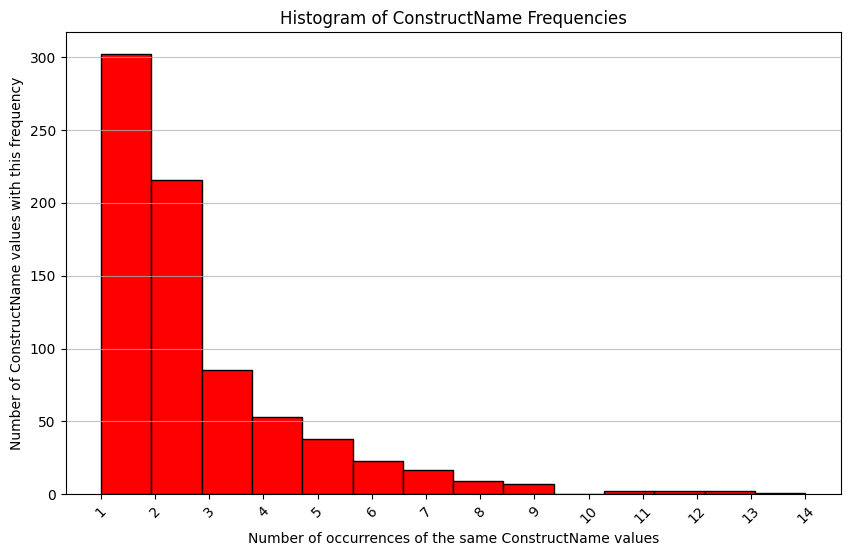

In [85]:
# Plotting the frequency of different ConstructNames
construct_name_counts = train_df['ConstructName'].value_counts()
print(f"Median frequency of ConstructName: {construct_name_counts.median()}")
print(f"Average frequency of ConstructName: {construct_name_counts.mean()}")

plt.figure(figsize=(10, 6))
plt.hist(construct_name_counts, bins=max(construct_name_counts.value_counts().index), color='red', edgecolor='black')
plt.title('Histogram of ConstructName Frequencies')
plt.xlabel('Number of occurrences of the same ConstructName values')
plt.ylabel('Number of ConstructName values with this frequency')
plt.xticks(range(min(construct_name_counts.value_counts().index), max(construct_name_counts.value_counts().index) + 1), rotation=45)
plt.grid(axis='y', alpha=0.75)

**Explanation of the graph and statistics**

As seen from the histogram above, over 300 different `ConstructName` values occur only once in the training dataset. The graph also shows that no `ConstructName` value occurs in the dataset more then 14 times.

The average frequency is approx. 2.47, which means that on average every `ConstructName` occurs in the dataset 2.47 times. The mean value of this frequency is then equal to 2.

**`ConstructName` values lengths**

Analyzing lengths (in tokens) of `ConstructName` values and plot histogram of these lengths.

Median Length: 60.0
Mean Length: 65.59550561797752
Standard Deviation: 27.868575418375336
Min Length: 14
Max Length: 194


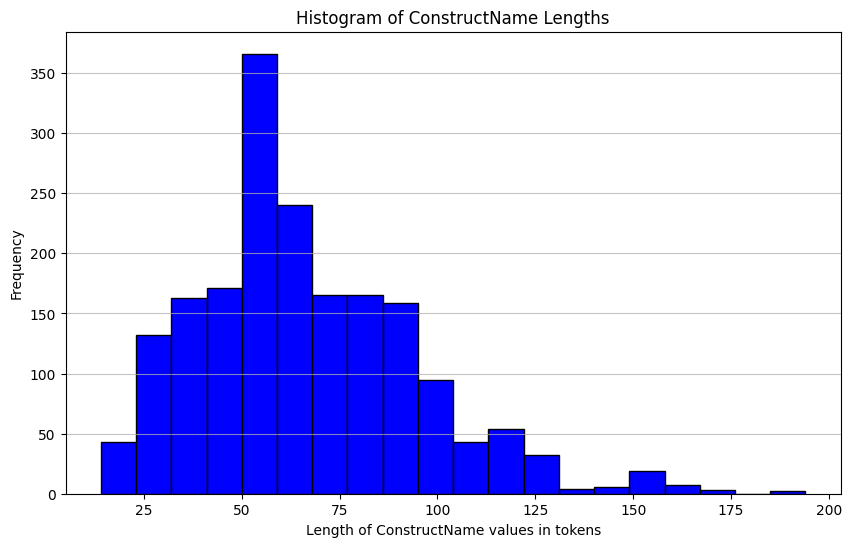

In [86]:
# Calculate lengths of ConstructName values
lengths = train_df['ConstructName'].str.len()

mean_length = lengths.mean()
min_length = lengths.min()
max_length = lengths.max()
median_length = lengths.median()
std_dev_length = lengths.std()
print(f'Median Length: {median_length}')
print(f'Mean Length: {mean_length}')
print(f'Standard Deviation: {std_dev_length}')
print(f'Min Length: {min_length}')
print(f'Max Length: {max_length}')

# Create a histogram of the lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=20, color='blue', edgecolor='black')
plt.title('Histogram of ConstructName Lengths')
plt.xlabel('Length of ConstructName values in tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

As seen above, most of the `ConstructName` values have a length between 35 and 95 tokens.

Some of the values (especially the ones with length over 125) seem suspicious. Let examine the lengths a bit more, and check for possible outliers.

**Outlier detection**

I check potential outliers using interquartile range (IQR). I mark values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR as potential outliers and examine them more.

In [87]:
# Step 1: Calculate lengths of ConstructName values
train_df['ConstructName_Length'] = train_df['ConstructName'].str.len()

# Step 3: Identify outliers using the IQR method
Q1 = train_df['ConstructName_Length'].quantile(0.25)
Q3 = train_df['ConstructName_Length'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = train_df[(train_df['ConstructName_Length'] < lower_bound) | (train_df['ConstructName_Length'] > upper_bound)]

# Print outliers
print("After calculating the IQR the number of potential outliers is:", outliers.shape[0])

train_df.drop(columns='ConstructName_Length', inplace=True)

After calculating the IQR the number of potential outliers is: 41


There is 41 values that are potential outliers, but after examining all of them by hand they seem to be valid `ConstructName` values.

### Examine SubjectName column

**Plot SubjectName frequencies**

Plot distribution of `SubjectName` values occurrence frequencies. (same as for `ConstructName` before)

I.E.: 
- On y-axis: How many different `SubjectName` values occur the same number of times
- On x-axis: The number of times the same `SubjectName` value occurs in the training dataset

Median frequency of SubjectName: 9.0
Average frequency of SubjectName: 11.466257668711657


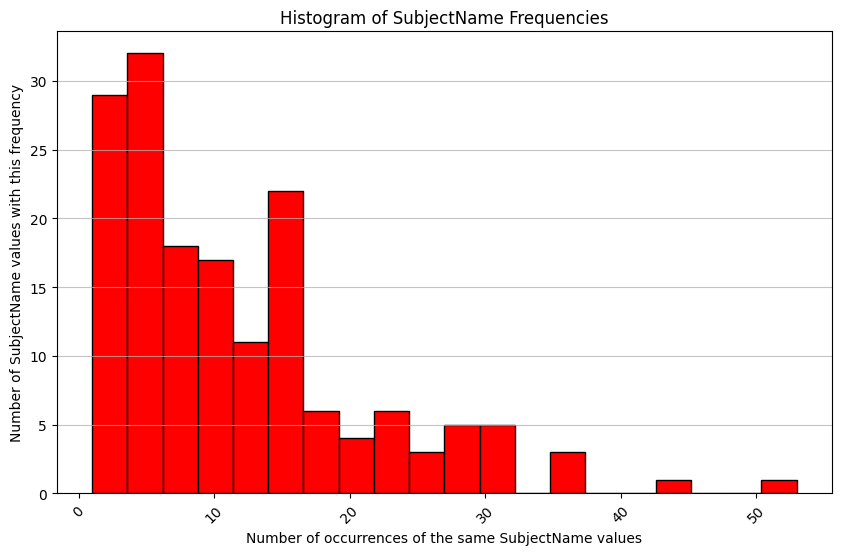

In [88]:
# Plotting the frequency of different SubjectNames as a histogram
subject_names_counts = train_df['SubjectName'].value_counts()
print(f"Median frequency of SubjectName: {subject_names_counts.median()}")
print(f"Average frequency of SubjectName: {subject_names_counts.mean()}")

plt.figure(figsize=(10, 6))
plt.hist(subject_names_counts, bins=20, color='red', edgecolor='black')
plt.title('Histogram of SubjectName Frequencies')
plt.xlabel('Number of occurrences of the same SubjectName values')
plt.ylabel('Number of SubjectName values with this frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

Most `SubjectName` values only occur in the training dataset only a handful of times apart from two `SubejctName` values that occur more then 40 and 50 times, but that is still not a frequency that is concerning more model training.

**`SubjectName` values lengths**

Analyzing lengths (in tokens) of `SubjectName` values and plot histogram of these lengths.

Median Length: 24.0
Mean Length: 25.392723381487425
Standard Deviation: 11.95664323596537
Min Length: 4
Max Length: 64


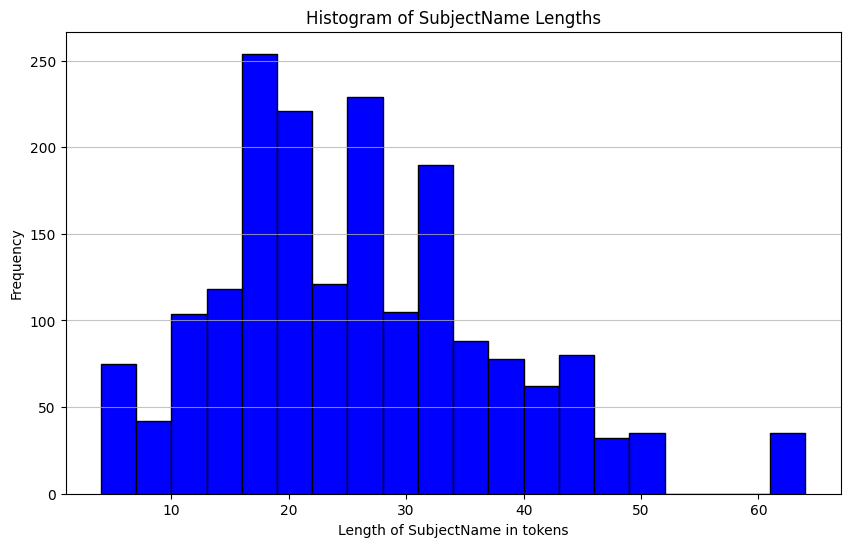

In [89]:
# Calculate lengths of SubjectName values
lengths = train_df['SubjectName'].str.len()

mean_length = lengths.mean()
min_length = lengths.min()
max_length = lengths.max()
median_length = lengths.median()
std_dev_length = lengths.std()
print(f'Median Length: {median_length}')
print(f'Mean Length: {mean_length}')
print(f'Standard Deviation: {std_dev_length}')
print(f'Min Length: {min_length}')
print(f'Max Length: {max_length}')

# Create a histogram of the lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=20, color='blue', edgecolor='black')
plt.title('Histogram of SubjectName Lengths')
plt.xlabel('Length of SubjectName in tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

The lengths seem reasonably distributed, apart from a few values that have a length of over 60 tokens. But after examining these values, they seem to be again valid `SubjectName` values.

### Examine QuestionText

In [90]:
# Identify rows with the same 'ConstructName', 'SubjectName', and 'QuestionText'
duplicate_rows = train_df.groupby(['ConstructName', 'SubjectName', 'QuestionText']).filter(lambda x: len(x) > 1)

# Extract the QuestionIds of the duplicates
duplicate_question_ids = duplicate_rows['QuestionId']

# Print the QuestionIds
if not duplicate_question_ids.empty:
    print("QuestionIds of the duplicates (both original and duplicates):")
    print(duplicate_question_ids.reset_index(drop=True))  # Reset index for cleaner output
else:
    print("There are no duplicates for 'ConstructName', 'SubjectName', and 'QuestionText'.")

QuestionIds of the duplicates (both original and duplicates):
0       68
1       74
2      316
3      460
4      464
5      501
6      512
7      552
8      610
9      683
10     731
11     977
12    1105
13    1116
14    1158
15    1198
16    1209
17    1296
18    1303
19    1313
20    1348
21    1832
Name: QuestionId, dtype: int64


**`QuestionText` values lengths**

Analyzing lengths (in tokens) of `QuestionText` values and plot histogram of these lengths.

Median Length: 121.0
Mean Length: 160.60032102728732
Standard Deviation: 134.455493300563
Min Length: 13
Max Length: 1253


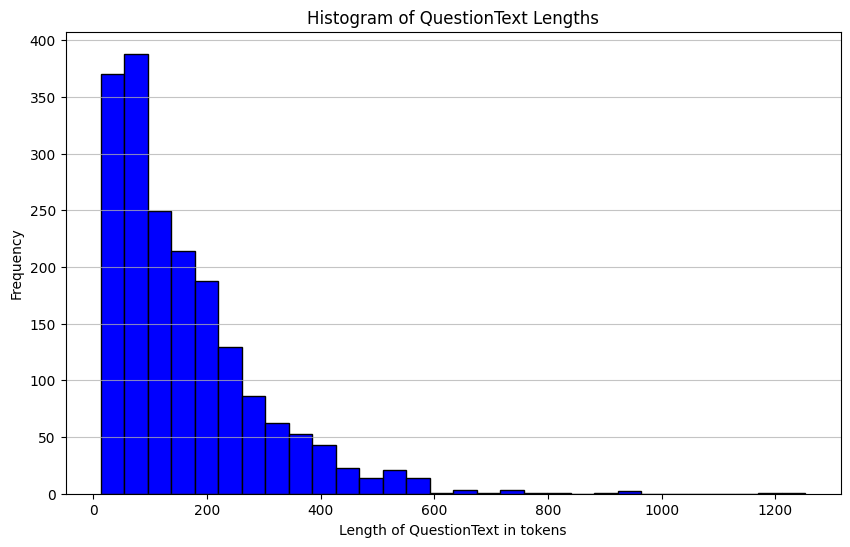

In [91]:
# Calculate lengths of QuestionText values
lengths = train_df['QuestionText'].str.len()

mean_length = lengths.mean()
min_length = lengths.min()
max_length = lengths.max()
median_length = lengths.median()
std_dev_length = lengths.std()
print(f'Median Length: {median_length}')
print(f'Mean Length: {mean_length}')
print(f'Standard Deviation: {std_dev_length}')
print(f'Min Length: {min_length}')
print(f'Max Length: {max_length}')

# Create a histogram of the lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=30, color='blue', edgecolor='black')
plt.title('Histogram of QuestionText Lengths')
plt.xlabel('Length of QuestionText in tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Concat ConstructName, SubjectName and QuestionText columns
Since all of these three columns are a part of the whole math assignment and I will later use a model to embedd them, it would be suitable to have them concatenated into a single string and examine that string then.

Therefore I concatenate column called `ConstructName`, `SubjectName` and `QuestionText` into a single column called `WholeAssignment`.

In [92]:
train_df['WholeAssignment'] = train_df['ConstructName'] + '. ' + train_df['SubjectName'] + '. ' + train_df['QuestionText']
print(f"Example of a whole assignment value: \n {train_df['WholeAssignment'][0]}")

Example of a whole assignment value: 
 Use the order of operations to carry out calculations involving powers. BIDMAS. \[
3 \times 2+4-5
\]
Where do the brackets need to go to make the answer equal \( 13 \) ?


**`WholeAssignment` value lengths**

Analyzing lengths (in tokens) of `WholeAssignment` values and plot histogram of these lengths.

Median Length: 218.0
Mean Length: 255.58855002675227
Standard Deviation: 141.94068753092202
Min Length: 58
Max Length: 1408


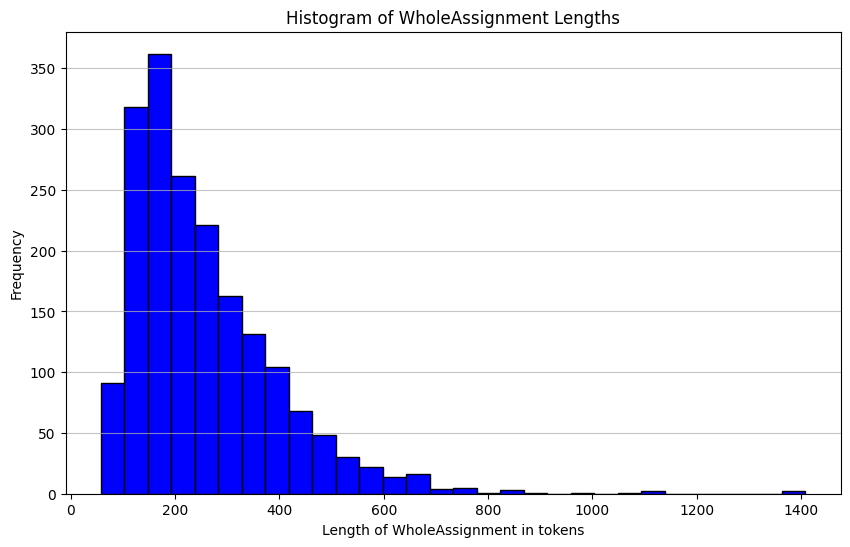

In [93]:
# Calculate lengths of WholeAssignment values
lengths = train_df['WholeAssignment'].str.len()

mean_length = lengths.mean()
min_length = lengths.min()
max_length = lengths.max()
median_length = lengths.median()
std_dev_length = lengths.std()
print(f'Median Length: {median_length}')
print(f'Mean Length: {mean_length}')
print(f'Standard Deviation: {std_dev_length}')
print(f'Min Length: {min_length}')
print(f'Max Length: {max_length}')

# Create a histogram of the lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=30, color='blue', edgecolor='black')
plt.title('Histogram of WholeAssignment Lengths')
plt.xlabel('Length of WholeAssignment in tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Apart from a few WholeAssignment values, most of them are bellow 800 tokens, which is a feasible length to process in a single context window for most embedding models. 

### Examine Misconceptions inside the Training Dataset
Examine how distributed are MisconceptionIds in the training dataset.

To do that I have to first reformat the training dataset. 

**Wide to Long Train DatasetFormatting**


Now there are multiple columns for different `AnswerTexts` (AnswerAText, AnswerBText, ...) and also multiple columns for different `MisconceptionIds` (MisconceptionAId, MisconceptionBId, ...).

I would prefer to have a single column stating the `AnswerText` type (A, B, C or D) and a single column stating its value.<br>
And the same for `MisconceptionIds`.

In [94]:
def melt_df(df: pd.DataFrame) -> pd.DataFrame:
    # Convert the dataframe from wide format to long
    
    # Melt the daraframe for AnswerText columns
    df_melted = pd.melt(
        df[
            [
                "QuestionId",
                "WholeAssignment",
                "ConstructName",
                "SubjectName",
                "QuestionText",
                "CorrectAnswer",
                "ConstructId",
                "SubjectId",
                "AnswerAText",
                "AnswerBText",
                "AnswerCText",
                "AnswerDText"
            ]
        ],
        id_vars=["QuestionId", "WholeAssignment", "ConstructName", "SubjectName", "QuestionText", "CorrectAnswer", "ConstructId", "SubjectId"],
        var_name='Answer',
        value_name='Answer_value'
    )
    
    # Melt the dataframe for MisconceptionId columns
    df_misc_melted = pd.melt(
        df[
            [
                "MisconceptionAId",
                "MisconceptionBId",
                "MisconceptionCId",
                "MisconceptionDId"
            ]
        ],
        id_vars=[],
        var_name='Misconception',
        value_name='MisconceptionId'
        )
    
    # Concatenate the melted dataframes along the columns
    combined = pd.concat([df_melted, df_misc_melted], axis=1)
            
    return combined


train_df_long = melt_df(train_df)

print(f"So I go from the original wide format shape of: {train_df.shape}")
print(f"To a new long format shape of: {train_df_long.shape}")

So I go from the original wide format shape of: (1869, 16)
To a new long format shape of: (7476, 12)


So I go from the original (wide) dataset looking like this:

In [95]:
display(HTML(f'<div class="dataframe-container">{train_df.head().to_html(index=False)}</div>'))

QuestionId,ConstructId,ConstructName,SubjectId,SubjectName,CorrectAnswer,QuestionText,AnswerAText,AnswerBText,AnswerCText,AnswerDText,MisconceptionAId,MisconceptionBId,MisconceptionCId,MisconceptionDId,WholeAssignment
0,856,Use the order of operations to carry out calculations involving powers,33,BIDMAS,A,\[\n3 \times 2+4-5\n\]\nWhere do the brackets need to go to make the answer equal \( 13 \) ?,\( 3 \times(2+4)-5 \),\( 3 \times 2+(4-5) \),\( 3 \times(2+4-5) \),Does not need brackets,NaN,NaN,NaN,1672.0,Use the order of operations to carry out calculations involving powers. BIDMAS. \[\n3 \times 2+4-5\n\]\nWhere do the brackets need to go to make the answer equal \( 13 \) ?
1,1612,Simplify an algebraic fraction by factorising the numerator,1077,Simplifying Algebraic Fractions,D,"Simplify the following, if possible: \( \frac{m^{2}+2 m-3}{m-3} \)",\( m+1 \),\( m+2 \),\( m-1 \),Does not simplify,2142.0,143.0,2142.0,NaN,"Simplify an algebraic fraction by factorising the numerator. Simplifying Algebraic Fractions. Simplify the following, if possible: \( \frac{m^{2}+2 m-3}{m-3} \)"
2,2774,Calculate the range from a list of data,339,Range and Interquartile Range from a List of Data,B,"Tom and Katie are discussing the \( 5 \) plants with these heights:\n\( 24 \mathrm{~cm}, 17 \mathrm{~cm}, 42 \mathrm{~cm}, 26 \mathrm{~cm}, 13 \mathrm{~cm} \)\nTom says if all the plants were cut in half, the range wouldn't change.\nKatie says if all the plants grew by \( 3 \mathrm{~cm} \) each, the range wouldn't change.\nWho do you agree with?",Only\nTom,Only\nKatie,Both Tom and Katie,Neither is correct,1287.0,NaN,1287.0,1073.0,"Calculate the range from a list of data. Range and Interquartile Range from a List of Data. Tom and Katie are discussing the \( 5 \) plants with these heights:\n\( 24 \mathrm{~cm}, 17 \mathrm{~cm}, 42 \mathrm{~cm}, 26 \mathrm{~cm}, 13 \mathrm{~cm} \)\nTom says if all the plants were cut in half, the range wouldn't change.\nKatie says if all the plants grew by \( 3 \mathrm{~cm} \) each, the range wouldn't change.\nWho do you agree with?"
3,2377,Recall and use the intersecting diagonals properties of a rectangle,88,Properties of Quadrilaterals,C,The angles highlighted on this rectangle with different length sides can never be... ![A rectangle with the diagonals drawn in. The angle on the right hand side at the centre is highlighted in red and the angle at the bottom at the centre is highlighted in yellow.](),acute,obtuse,\( 90^{\circ} \),Not enough information,1180.0,1180.0,NaN,1180.0,Recall and use the intersecting diagonals properties of a rectangle. Properties of Quadrilaterals. The angles highlighted on this rectangle with different length sides can never be... ![A rectangle with the diagonals drawn in. The angle on the right hand side at the centre is highlighted in red and the angle at the bottom at the centre is highlighted in yellow.]()
4,3387,Substitute positive integer values into formulae involving powers or roots,67,Substitution into Formula,A,The equation \( f=3 r^{2}+3 \) is used to find values in the table below. What is the value covered by the star? \begin{tabular}{|c|c|c|c|c|}\n\hline\( r \) & \( 1 \) & \( 2 \) & \( 3 \) & \( 4 \) \\\n\hline\( f \) & \( 6 \) & \( 15 \) & \( \color{gold}\bigstar \) & \\\n\hline\n\end{tabular},\( 30 \),\( 27 \),\( 51 \),\( 24 \),NaN,NaN,NaN,1818.0,Substitute positive integer values into formulae involving powers or roots. Substitution into Formula. The equation \( f=3 r^{2}+3 \) is used to find values in the table below. What is the value covered by the star? \begin{tabular}{|c|c|c|c|c|}\n\hline\( r \) & \( 1 \) & \( 2 \) & \( 3 \) & \( 4 \) \\\n\hline\( f \) & \( 6 \) & \( 15 \) & \( \color{gold}\bigstar \) & \\\n\hline\n\end{tabular}


To a new (long) dataset looking like this:

In [96]:
display(HTML(f'<div class="dataframe-container">{train_df_long.head().to_html(index=False)}</div>'))

QuestionId,WholeAssignment,ConstructName,SubjectName,QuestionText,CorrectAnswer,ConstructId,SubjectId,Answer,Answer_value,Misconception,MisconceptionId
0,Use the order of operations to carry out calculations involving powers. BIDMAS. \[\n3 \times 2+4-5\n\]\nWhere do the brackets need to go to make the answer equal \( 13 \) ?,Use the order of operations to carry out calculations involving powers,BIDMAS,\[\n3 \times 2+4-5\n\]\nWhere do the brackets need to go to make the answer equal \( 13 \) ?,A,856,33,AnswerAText,\( 3 \times(2+4)-5 \),MisconceptionAId,NaN
1,"Simplify an algebraic fraction by factorising the numerator. Simplifying Algebraic Fractions. Simplify the following, if possible: \( \frac{m^{2}+2 m-3}{m-3} \)",Simplify an algebraic fraction by factorising the numerator,Simplifying Algebraic Fractions,"Simplify the following, if possible: \( \frac{m^{2}+2 m-3}{m-3} \)",D,1612,1077,AnswerAText,\( m+1 \),MisconceptionAId,2142.0
2,"Calculate the range from a list of data. Range and Interquartile Range from a List of Data. Tom and Katie are discussing the \( 5 \) plants with these heights:\n\( 24 \mathrm{~cm}, 17 \mathrm{~cm}, 42 \mathrm{~cm}, 26 \mathrm{~cm}, 13 \mathrm{~cm} \)\nTom says if all the plants were cut in half, the range wouldn't change.\nKatie says if all the plants grew by \( 3 \mathrm{~cm} \) each, the range wouldn't change.\nWho do you agree with?",Calculate the range from a list of data,Range and Interquartile Range from a List of Data,"Tom and Katie are discussing the \( 5 \) plants with these heights:\n\( 24 \mathrm{~cm}, 17 \mathrm{~cm}, 42 \mathrm{~cm}, 26 \mathrm{~cm}, 13 \mathrm{~cm} \)\nTom says if all the plants were cut in half, the range wouldn't change.\nKatie says if all the plants grew by \( 3 \mathrm{~cm} \) each, the range wouldn't change.\nWho do you agree with?",B,2774,339,AnswerAText,Only\nTom,MisconceptionAId,1287.0
3,Recall and use the intersecting diagonals properties of a rectangle. Properties of Quadrilaterals. The angles highlighted on this rectangle with different length sides can never be... ![A rectangle with the diagonals drawn in. The angle on the right hand side at the centre is highlighted in red and the angle at the bottom at the centre is highlighted in yellow.](),Recall and use the intersecting diagonals properties of a rectangle,Properties of Quadrilaterals,The angles highlighted on this rectangle with different length sides can never be... ![A rectangle with the diagonals drawn in. The angle on the right hand side at the centre is highlighted in red and the angle at the bottom at the centre is highlighted in yellow.](),C,2377,88,AnswerAText,acute,MisconceptionAId,1180.0
4,Substitute positive integer values into formulae involving powers or roots. Substitution into Formula. The equation \( f=3 r^{2}+3 \) is used to find values in the table below. What is the value covered by the star? \begin{tabular}{|c|c|c|c|c|}\n\hline\( r \) & \( 1 \) & \( 2 \) & \( 3 \) & \( 4 \) \\\n\hline\( f \) & \( 6 \) & \( 15 \) & \( \color{gold}\bigstar \) & \\\n\hline\n\end{tabular},Substitute positive integer values into formulae involving powers or roots,Substitution into Formula,The equation \( f=3 r^{2}+3 \) is used to find values in the table below. What is the value covered by the star? \begin{tabular}{|c|c|c|c|c|}\n\hline\( r \) & \( 1 \) & \( 2 \) & \( 3 \) & \( 4 \) \\\n\hline\( f \) & \( 6 \) & \( 15 \) & \( \color{gold}\bigstar \) & \\\n\hline\n\end{tabular},A,3387,67,AnswerAText,\( 30 \),MisconceptionAId,NaN


**Dropping rows where MisconceptionId is NaN**

Since these rows do not give any additional information about MisconceptionIds.

In [97]:
# Count and print the number of NaN values in MisconceptionId
nan_count = train_df_long['MisconceptionId'].isna().sum()
print(f'Number of NaN values in MisconceptionId before dropping them: {nan_count}')
print(f'Dataset shape before dropping them: {train_df_long.shape}')

# Drop rows where MisconceptionId is NaN
train_df_long = train_df_long.dropna(subset=['MisconceptionId'])
print(f'Dataset shape after dropping them: {train_df_long.shape}')

Number of NaN values in MisconceptionId before dropping them: 3106
Dataset shape before dropping them: (7476, 12)
Dataset shape after dropping them: (4370, 12)


As seen from the dataset shapes, there were quite a few rows do not contain any misconception. I have dropped these rows since they would not be useful for any model training

In [98]:
#save df
train_df_long.to_csv('./data/train_df_long.csv', index=False)

**Plot MisconceptionId frequencies**

Plot distribution of `MisconceptionId` values occurrence frequencies. (same as for `ConstructName` before).

I.E.: 
- On y-axis: How many different `MisconceptionId` values occur the same number of times
- On x-axis: The number of times the same `MisconceptionId` value occurs in the training dataset

Median frequency of SubjectName: 2.0
Average frequency of SubjectName: 2.724438902743142
Minimum frequency of SubjectName: 1
Maximum frequency of SubjectName: 54


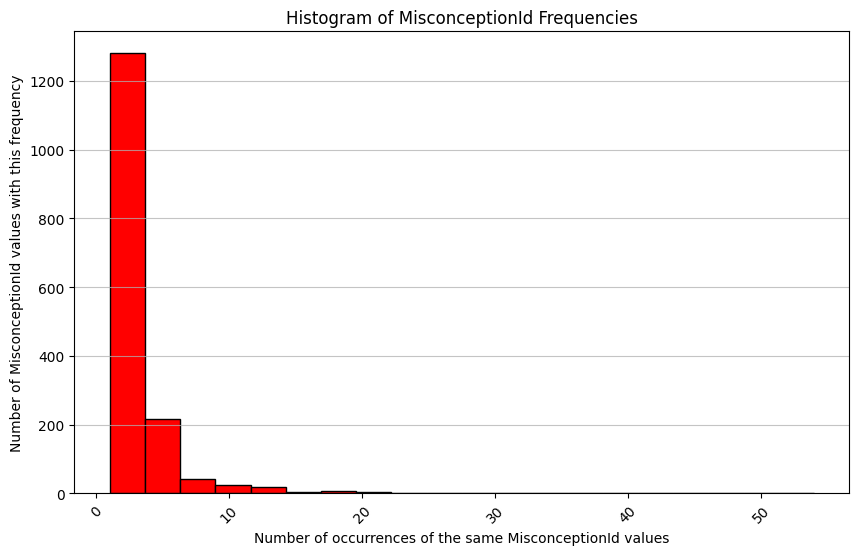

In [99]:
# Plotting the frequency of different SubjectNames as a histogram
misc_id_counts = train_df_long['MisconceptionId'].value_counts()
print(f"Median frequency of SubjectName: {misc_id_counts.median()}")
print(f"Average frequency of SubjectName: {misc_id_counts.mean()}")
print(f"Minimum frequency of SubjectName: {misc_id_counts.min()}")
print(f"Maximum frequency of SubjectName: {misc_id_counts.max()}")

plt.figure(figsize=(10, 6))
plt.hist(misc_id_counts, bins=20, color='red', edgecolor='black')
plt.title('Histogram of MisconceptionId Frequencies')
plt.xlabel('Number of occurrences of the same MisconceptionId values')
plt.ylabel('Number of MisconceptionId values with this frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

Most misconceptions do not occur many time in the training dataset. Which is good that the training data is not imbalanced.

**Number of Unique `MisconceptionId` values**

In [100]:
# Count unique misconceptions in MisconceptionId
unique_misconceptions = train_df_long['MisconceptionId'].nunique()

print(f'Number of unique misconceptions in MisconceptionId column in training dataset: {unique_misconceptions}')
print(f'Number of total misconceptions in misconception mapping dataset: {misconception_mapping.shape[0]}')
print(f'Therefore the number of misconceptions that are not present in training dataset is: {misconception_mapping.shape[0] - unique_misconceptions}')

Number of unique misconceptions in MisconceptionId column in training dataset: 1604
Number of total misconceptions in misconception mapping dataset: 2587
Therefore the number of misconceptions that are not present in training dataset is: 983


The numbers above show, that more then 1/3 of all the possible misconceptions is missing in the training dataset.<br> And from the graph above we know that the ones that are in the training dataset only occur in the dataset a handful of times.

Therefore, models that depend on traditional multi-class classification techniques are likely to be ineffective in this scenario. These models operate by calculating the probabilities of an input belonging to a specific class. However, given the large number of classes and the fact that some of them are not represented in the training dataset, training such models is probably not gonna useful.

I might instead have to use `WholeAssignment` column values and `Answer` values as inputs and use some form of similarity search to map it to a correct misconception.

# Model Selection and Train-Test Split

## Train-Test Split
Regardless of what model I choose to use for the task, I need a dataset for training and testing the model. As seen above in Data Preprocessing Chapter I cannot use the test dataset provided by the competition for testing since not only contains just 3 rows but it is also missing the columns I am trying to predict.

Therefore, I split the training dataset provided into two sets: train (85% of the original training dataset) and test (15% of the original training dataset). However, the test set will be rather used as a validation/development set since the real test set is hidden from me and Kaggle uses it for the models evaluation.

The shapes of the newly created train/test datasets are the following:

In [101]:
from sklearn.model_selection import train_test_split
# Load the DataFrame from the CSV file
train_df_long = pd.read_csv('./data/train_df_long.csv')

# Split the DataFrame into training and test sets
train_df_train, train_df_test = train_test_split(train_df_long, test_size=0.15, random_state=42)

# Save the DataFrames to CSV files
train_df_train.to_csv('./data/train_df_train.csv', index=False)
train_df_test.to_csv('./data/train_df_test.csv', index=False)

print(f"Shape of Train dataset: {train_df_train.shape}")
print(f"Shape of Test dataset: {train_df_test.shape}")

Shape of Train dataset: (3714, 12)
Shape of Test dataset: (656, 12)


## Model Selection

As discussed at the end of the previous chapter I need to use some form of similarity search for the task.

I will try two approaches, one is similarity search between `WholeAssigment` concatenated with `Answer` column values and `MisconceptionName` values. This approach is described in more detail in `similarity_search.html` (I recommend reading this file as the next one).

The second approach uses LLM to generate new misconceptions which are then mapped onto existing misconceptions using similarity search. This approach is described in more detail in `zero_shot.html` (this notebook also contains final evaluation). 

Also for both approaches I need to train/fine-tune embedding. This is process is described in `fine_tuning_bge_large.hmtl`  file.